# FPL Squad Optimisation — 3-4-3 Formation Strategy

This notebook builds an **alternative squad** calibrated for a **3-4-3 playing formation**.

## Formation Logic

FPL squads are always 15 players (2 GK · 5 DEF · 5 MID · 3 FWD). The formation determines your **starting 11**:

| Position | Squad Size | Starters (3-4-3) | Bench | Implication |
|----------|-----------|------------------|-------|-------------|
| GK  | 2 | 1 | 1 | Bench GK can be budget — low priority |
| DEF | 5 | 3 | 2 | 2 bench slots → some budget options viable |
| MID | 5 | 4 | 1 | High quality needed — most starters |
| FWD | 3 | 3 | 0 | All forwards play — premium picks required |

## Approach: Formation Multipliers

We apply **formation multipliers** to recommendation scores *before* optimisation. This incentivises the solver to prioritise premium FWDs and quality MIDs, while accepting cheaper DEFs and budget GKs.

| Position | Multiplier | Rationale |
|----------|-----------|----------|
| GK  | 0.70 | Only 1 starts; bench slot is pure cover |
| DEF | 0.85 | 2 of 5 are bench — value picks acceptable |
| MID | 1.15 | 4 of 5 start — quality across the board |
| FWD | 1.30 | All 3 start — no depth, must be premium |

**Key difference from baseline:** the adjusted scores shift the budget upward toward FWD/MID and free up cost savings on DEF/GK.

In [9]:
# Imports
import sys
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

try:
    from pulp import (
        LpProblem, LpMaximize, LpVariable, lpSum,
        LpBinary, PULP_CBC_CMD
    )
    HAS_PULP = True
    print("✓ PuLP available — using exact ILP optimisation")
except ImportError:
    HAS_PULP = False
    print("⚠ PuLP not available — will use greedy fallback")

sys.path.insert(0, '/Users/aaryansehgal/Documents/Codex/2026-07-27/files-mentioned-by-the-user-i/outputs/fpl_data_pipeline/src')
from fpl_pipeline.storage import load_bootstrap_snapshot, extract_players_from_bootstrap

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
matplotlib.rcParams['figure.dpi'] = 100

print("✓ All libraries imported")

✓ PuLP available — using exact ILP optimisation
✓ All libraries imported


## Load Player Data & Define Formation Parameters

In [10]:
# ── Constants ────────────────────────────────────────────────────────────────
POSITION_MAP = {1: "GK", 2: "DEF", 3: "MID", 4: "FWD"}
BUDGET_TENTHS = 1000  # £100m

SQUAD_REQUIREMENTS = {
    1: {"name": "Goalkeeper", "count": 2},
    2: {"name": "Defender",   "count": 5},
    3: {"name": "Midfielder", "count": 5},
    4: {"name": "Forward",    "count": 3},
}

# 3-4-3 formation: how many players per position START each week
FORMATION_STARTERS = {1: 1, 2: 3, 3: 4, 4: 3}

# Formation multipliers applied to recommendation scores
# Higher = optimizer will spend more to get better players in that slot
FORMATION_MULTIPLIERS = {
    1: 0.70,   # GK  — budget bench cover acceptable
    2: 0.85,   # DEF — 2 bench slots allow cheaper options
    3: 1.15,   # MID — 4 of 5 start, quality important
    4: 1.30,   # FWD — all 3 start, no cover: premium picks
}

# Optimisation weights (same as latest baseline)
SCORE_WEIGHT      = 0.6   # 60% adjusted recommendation score
EFFICIENCY_WEIGHT = 0.4   # 40% cost efficiency (£ per point)

# ── Load Data ────────────────────────────────────────────────────────────────
BOOTSTRAP_PATH = (
    '/Users/aaryansehgal/Documents/Codex/2026-07-27/files-mentioned-by-the-user-i'
    '/outputs/fpl_data_pipeline/data/raw/season=2026-27'
    '/endpoint=bootstrap-static/date=2026-07-27/142933_543435_97e84bead4fe.json'
)

bootstrap_data = load_bootstrap_snapshot(BOOTSTRAP_PATH)
players_df = extract_players_from_bootstrap(bootstrap_data)

# Generate recommendation scores (same seed as baseline for fair comparison)
np.random.seed(42)
players_df['recommendation_score'] = (
    (players_df['value_millions'] / players_df['value_millions'].max()) * 1.5 +
    np.random.normal(0, 0.15, len(players_df))
)
players_df['recommendation_score'] = np.maximum(0.1, players_df['recommendation_score'])
players_df['value_per_point'] = players_df['value_millions'] / players_df['recommendation_score']
players_df = players_df[players_df['value_millions'] > 0].copy()

# ── Apply Formation Multipliers ──────────────────────────────────────────────
players_df['formation_multiplier'] = players_df['position_id'].map(FORMATION_MULTIPLIERS)
players_df['adjusted_score']       = players_df['recommendation_score'] * players_df['formation_multiplier']
# Recalculate value_per_point using adjusted score so efficiency reflects formation priority
players_df['adjusted_vpp']         = players_df['value_millions'] / players_df['adjusted_score']

print(f"✓ Loaded {len(players_df)} players from 2026-27 bootstrap snapshot")
print()
print("Formation multipliers applied:")
for pos_id, mult in FORMATION_MULTIPLIERS.items():
    pos_label = POSITION_MAP[pos_id]
    starters  = FORMATION_STARTERS[pos_id]
    squad_sz  = SQUAD_REQUIREMENTS[pos_id]['count']
    bench_sz  = squad_sz - starters
    direction = "▲ premium" if mult > 1.0 else ("▼ budget" if mult < 0.85 else "→ moderate")
    print(f"  {pos_label:3s}  ×{mult:.2f}  ({starters}/{squad_sz} start, {bench_sz} bench)  {direction}")

✓ Loaded 563 players from 2026-27 bootstrap snapshot

Formation multipliers applied:
  GK   ×0.70  (1/2 start, 1 bench)  ▼ budget
  DEF  ×0.85  (3/5 start, 2 bench)  → moderate
  MID  ×1.15  (4/5 start, 1 bench)  ▲ premium
  FWD  ×1.30  (3/3 start, 0 bench)  ▲ premium


## Optimisation Functions (Formation-Aware)

In [3]:
def optimize_squad_343_ilp(players_df, budget_tenths=1000,
                            score_weight=0.6, efficiency_weight=0.4):
    """
    ILP squad optimisation using formation-adjusted scores.
    Objective: Maximise (score_weight × norm_adjusted_score + efficiency_weight × efficiency_score)
    The adjusted_score already encodes formation priorities via FORMATION_MULTIPLIERS.
    """
    if not HAS_PULP:
        return None

    df = players_df.copy()

    # Normalise adjusted score → 0-1
    max_adj = df['adjusted_score'].max()
    df['norm_adj_score'] = df['adjusted_score'] / max_adj if max_adj > 0 else 0

    # Efficiency: invert adjusted_vpp so cheaper-per-point scores higher
    max_avpp = df['adjusted_vpp'].max()
    df['efficiency_score'] = (max_avpp / df['adjusted_vpp']).clip(upper=2.0)
    df['efficiency_score'] = df['efficiency_score'] / df['efficiency_score'].max()

    df['combined_score'] = (
        score_weight      * df['norm_adj_score'] +
        efficiency_weight * df['efficiency_score']
    )

    prob = LpProblem("FPL_Squad_343", LpMaximize)
    x = {idx: LpVariable(f"p_{row['player_id']}", cat='Binary')
         for idx, row in df.iterrows()}

    prob += lpSum(x[idx] * df.loc[idx, 'combined_score'] for idx in x)
    prob += lpSum(x[idx] for idx in x) == 15
    prob += lpSum(x[idx] * players_df.loc[idx, 'value_tenths'] for idx in x) <= budget_tenths

    for pos_id in [1, 2, 3, 4]:
        req = SQUAD_REQUIREMENTS[pos_id]['count']
        pos_idx = players_df[players_df['position_id'] == pos_id].index.tolist()
        prob += lpSum(x[idx] for idx in pos_idx) == req

    prob.solve(PULP_CBC_CMD(msg=0))

    selected = [idx for idx in x if x[idx].varValue == 1]
    squad = players_df.loc[selected].copy()
    return squad, prob.objective.value()


def optimize_squad_343_greedy(players_df, budget_tenths=1000,
                               score_weight=0.6, efficiency_weight=0.4):
    """Greedy fallback using formation-adjusted scores."""
    df = players_df.copy()

    max_adj = df['adjusted_score'].max()
    df['norm_adj_score'] = df['adjusted_score'] / max_adj if max_adj > 0 else 0

    max_avpp = df['adjusted_vpp'].max()
    df['efficiency_score'] = (max_avpp / df['adjusted_vpp']).clip(upper=2.0)
    df['efficiency_score'] = df['efficiency_score'] / df['efficiency_score'].max()

    df['combined_score'] = (
        score_weight      * df['norm_adj_score'] +
        efficiency_weight * df['efficiency_score']
    )

    squad, used, remaining = [], set(), budget_tenths
    for pos_id in [1, 2, 3, 4]:
        req      = SQUAD_REQUIREMENTS[pos_id]['count']
        pos_pool = df[(players_df['position_id'] == pos_id) &
                      (~df.index.isin(used))].sort_values('combined_score', ascending=False)
        selected = 0
        for idx, row in pos_pool.iterrows():
            if selected >= req:
                break
            if players_df.loc[idx, 'value_tenths'] <= remaining:
                squad.append(idx)
                used.add(idx)
                remaining -= players_df.loc[idx, 'value_tenths']
                selected  += 1

    squad_df = players_df.loc[squad].copy() if squad else pd.DataFrame()
    return squad_df, squad_df['recommendation_score'].sum() if len(squad_df) else 0


print("✓ Formation-aware optimisation functions defined")
print(f"  Score weight:      {SCORE_WEIGHT*100:.0f}%")
print(f"  Efficiency weight: {EFFICIENCY_WEIGHT*100:.0f}%")
print(f"  Formation:         3-4-3")

✓ Formation-aware optimisation functions defined
  Score weight:      60%
  Efficiency weight: 40%
  Formation:         3-4-3


## Run Optimisation

In [4]:
print("=" * 80)
print("3-4-3 FORMATION OPTIMISATION")
print("=" * 80)
print(f"\nObjective: {SCORE_WEIGHT*100:.0f}% formation-adjusted score + {EFFICIENCY_WEIGHT*100:.0f}% value efficiency")
print("Formation multipliers: GK×0.70  DEF×0.85  MID×1.15  FWD×1.30")

use_ilp = HAS_PULP
if use_ilp:
    result = optimize_squad_343_ilp(players_df, BUDGET_TENTHS, SCORE_WEIGHT, EFFICIENCY_WEIGHT)
    if result is None:
        print("⚠ ILP failed — falling back to greedy")
        use_ilp = False
    else:
        optimal_squad_343, _ = result
        print("\n✓ ILP optimisation successful")

if not use_ilp:
    optimal_squad_343, _ = optimize_squad_343_greedy(players_df, BUDGET_TENTHS, SCORE_WEIGHT, EFFICIENCY_WEIGHT)

optimal_squad_343 = optimal_squad_343.sort_values('position_id')
total_score_343   = optimal_squad_343['recommendation_score'].sum()
total_cost_343    = optimal_squad_343['value_tenths'].sum()
total_cost_m_343  = total_cost_343 / 10

print("\n" + "=" * 80)
print("3-4-3 OPTIMAL SQUAD")
print("=" * 80)
print(f"\nTotal players: {len(optimal_squad_343)}  |  Cost: £{total_cost_m_343:.1f}m  |  Score: {total_score_343:.3f}")
print(f"Budget remaining: £{(BUDGET_TENTHS - total_cost_343)/10:.1f}m")

for pos_id in [1, 2, 3, 4]:
    pos_sq    = optimal_squad_343[optimal_squad_343['position_id'] == pos_id].sort_values('recommendation_score', ascending=False)
    pos_cost  = pos_sq['value_millions'].sum()
    starters  = FORMATION_STARTERS[pos_id]
    squad_sz  = SQUAD_REQUIREMENTS[pos_id]['count']
    mult      = FORMATION_MULTIPLIERS[pos_id]
    print(f"\n{POSITION_MAP[pos_id]}s — {starters}/{squad_sz} start  ×{mult:.2f}  (£{pos_cost:.1f}m total)")
    for i, (_, p) in enumerate(pos_sq.iterrows(), 1):
        tag = "★" if i <= starters else "·"
        print(f"  {tag} {i}. {p['player_name']:35s} £{p['value_millions']:5.1f}m  Score: {p['recommendation_score']:.3f}  PPM: {p['value_per_point']:.2f}")

print("\n" + "=" * 80)
print("★ = expected starter  · = bench")
print("=" * 80)

3-4-3 FORMATION OPTIMISATION

Objective: 60% formation-adjusted score + 40% value efficiency
Formation multipliers: GK×0.70  DEF×0.85  MID×1.15  FWD×1.30

✓ ILP optimisation successful

3-4-3 OPTIMAL SQUAD

Total players: 15  |  Cost: £100.0m  |  Score: 14.263
Budget remaining: £0.0m

GKs — 1/2 start  ×0.70  (£9.0m total)
  ★ 1. Senne Lammens                       £  5.0m  Score: 0.793  PPM: 6.31
  · 2. Benjamin Lecomte                    £  4.0m  Score: 0.705  PPM: 5.67

DEFs — 3/5 start  ×0.85  (£22.5m total)
  ★ 1. Felipe Rodrigues da Silva           £  5.0m  Score: 0.946  PPM: 5.29
  ★ 2. Jake O'Brien                        £  5.0m  Score: 0.805  PPM: 6.21
  ★ 3. Lewis Dunk                          £  4.5m  Score: 0.805  PPM: 5.59
  · 4. Jake Bidwell                        £  4.0m  Score: 0.795  PPM: 5.03
  · 5. Paddy McNair                        £  4.0m  Score: 0.707  PPM: 5.66

MIDs — 4/5 start  ×1.15  (£41.5m total)
  ★ 1. Bruno Borges Fernandes              £ 12.0m  Score: 1.3

## Constraint Validation

In [5]:
print("CONSTRAINT VALIDATION — 3-4-3 Squad")
print("=" * 60)
all_valid = True

size_ok = len(optimal_squad_343) == 15
print(f"{'✓' if size_ok else '✗'} Squad size: {len(optimal_squad_343)} == 15")
all_valid = all_valid and size_ok

budget_ok = total_cost_343 <= BUDGET_TENTHS
print(f"{'✓' if budget_ok else '✗'} Budget: £{total_cost_m_343:.1f}m ≤ £{BUDGET_TENTHS/10:.1f}m")
all_valid = all_valid and budget_ok

for pos_id in [1, 2, 3, 4]:
    actual   = len(optimal_squad_343[optimal_squad_343['position_id'] == pos_id])
    required = SQUAD_REQUIREMENTS[pos_id]['count']
    ok       = actual == required
    print(f"{'✓' if ok else '✗'} {POSITION_MAP[pos_id]}: {actual} == {required}")
    all_valid = all_valid and ok

print()
print(f"OVERALL: {'✓ ALL CONSTRAINTS SATISFIED' if all_valid else '✗ CONSTRAINT VIOLATION DETECTED'}")
print("=" * 60)

CONSTRAINT VALIDATION — 3-4-3 Squad
✓ Squad size: 15 == 15
✓ Budget: £100.0m ≤ £100.0m
✓ GK: 2 == 2
✓ DEF: 5 == 5
✓ MID: 5 == 5
✓ FWD: 3 == 3

OVERALL: ✓ ALL CONSTRAINTS SATISFIED


## Comparison: 3-4-3 vs Baseline Squad

In [6]:
# Load baseline squad for comparison
BASELINE_CSV = '/tmp/fpl_optimal_squad.csv'
try:
    baseline_squad = pd.read_csv(BASELINE_CSV)
    has_baseline   = True
except FileNotFoundError:
    has_baseline   = False
    print("⚠ Baseline squad CSV not found — run squad_optimization.ipynb first")

if has_baseline:
    baseline_ids = set(baseline_squad['player_id'])
    squad_343_ids = set(optimal_squad_343['player_id'])

    retained  = baseline_ids & squad_343_ids
    dropped   = baseline_ids - squad_343_ids
    new_picks = squad_343_ids - baseline_ids

    print("=" * 80)
    print("SQUAD COMPARISON: Baseline (60/40) vs 3-4-3 Formation")
    print("=" * 80)

    # Budget by position
    print("\nBudget allocation by position:")
    print(f"{'Position':<8} {'Baseline':>12} {'3-4-3':>10} {'Δ':>8}")
    print("-" * 42)
    for pos_id in [1, 2, 3, 4]:
        bl_cost  = baseline_squad[baseline_squad['position_id'] == pos_id]['value_millions'].sum()
        new_cost = optimal_squad_343[optimal_squad_343['position_id'] == pos_id]['value_millions'].sum()
        delta    = new_cost - bl_cost
        arrow    = "▲" if delta > 0 else ("▼" if delta < 0 else "→")
        print(f"{POSITION_MAP[pos_id]:<8} £{bl_cost:>9.1f}m  £{new_cost:>7.1f}m  {arrow}{abs(delta):>5.1f}m")
    print("-" * 42)
    bl_total  = baseline_squad['value_millions'].sum()
    new_total = optimal_squad_343['value_millions'].sum()
    print(f"{'TOTAL':<8} £{bl_total:>9.1f}m  £{new_total:>7.1f}m")

    # Score comparison
    bl_score  = baseline_squad['recommendation_score'].sum()
    new_score = optimal_squad_343['recommendation_score'].sum()
    print(f"\nTotal recommendation score: {bl_score:.3f} → {new_score:.3f}  (Δ {new_score-bl_score:+.3f})")

    # Player changes
    print(f"\nPlayers retained ({len(retained)}): ", end="")
    retained_names = baseline_squad[baseline_squad['player_id'].isin(retained)]['player_name'].tolist()
    print(", ".join(retained_names) if retained_names else "none")

    print(f"\nDropped from baseline ({len(dropped)}):")
    for _, p in baseline_squad[baseline_squad['player_id'].isin(dropped)].iterrows():
        print(f"  - {p['player_name']:35s} {POSITION_MAP[p['position_id']]}  £{p['value_millions']:.1f}m  Score: {p['recommendation_score']:.3f}")

    print(f"\nNew picks in 3-4-3 squad ({len(new_picks)}):")
    for _, p in optimal_squad_343[optimal_squad_343['player_id'].isin(new_picks)].sort_values('position_id').iterrows():
        print(f"  + {p['player_name']:35s} {POSITION_MAP[p['position_id']]}  £{p['value_millions']:.1f}m  Score: {p['recommendation_score']:.3f}")

    print("\n" + "=" * 80)

SQUAD COMPARISON: Baseline (60/40) vs 3-4-3 Formation

Budget allocation by position:
Position     Baseline      3-4-3        Δ
------------------------------------------
GK       £      9.0m  £    9.0m  →  0.0m
DEF      £     26.5m  £   22.5m  ▼  4.0m
MID      £     38.5m  £   41.5m  ▲  3.0m
FWD      £     26.0m  £   27.0m  ▲  1.0m
------------------------------------------
TOTAL    £    100.0m  £  100.0m

Total recommendation score: 14.305 → 14.263  (Δ -0.042)

Players retained (12): Senne Lammens, Benjamin Lecomte, Felipe Rodrigues da Silva, Jake O'Brien, Lewis Dunk, Jake Bidwell, Bruno Borges Fernandes, Ismaïla Sarr, Morgan Gibbs-White, Bruno Guimarães Rodriguez Moura, Erling Haaland, Brian Brobbey

Dropped from baseline (3):
  - Gabriel dos Santos Magalhães        DEF  £8.0m  Score: 1.003
  - Jesurun Rak-Sakyi                   MID  £5.0m  Score: 0.831
  - Sindre Walle Egeli                  FWD  £4.5m  Score: 0.749

New picks in 3-4-3 squad (3):
  + Paddy McNair                  

## Visualisations

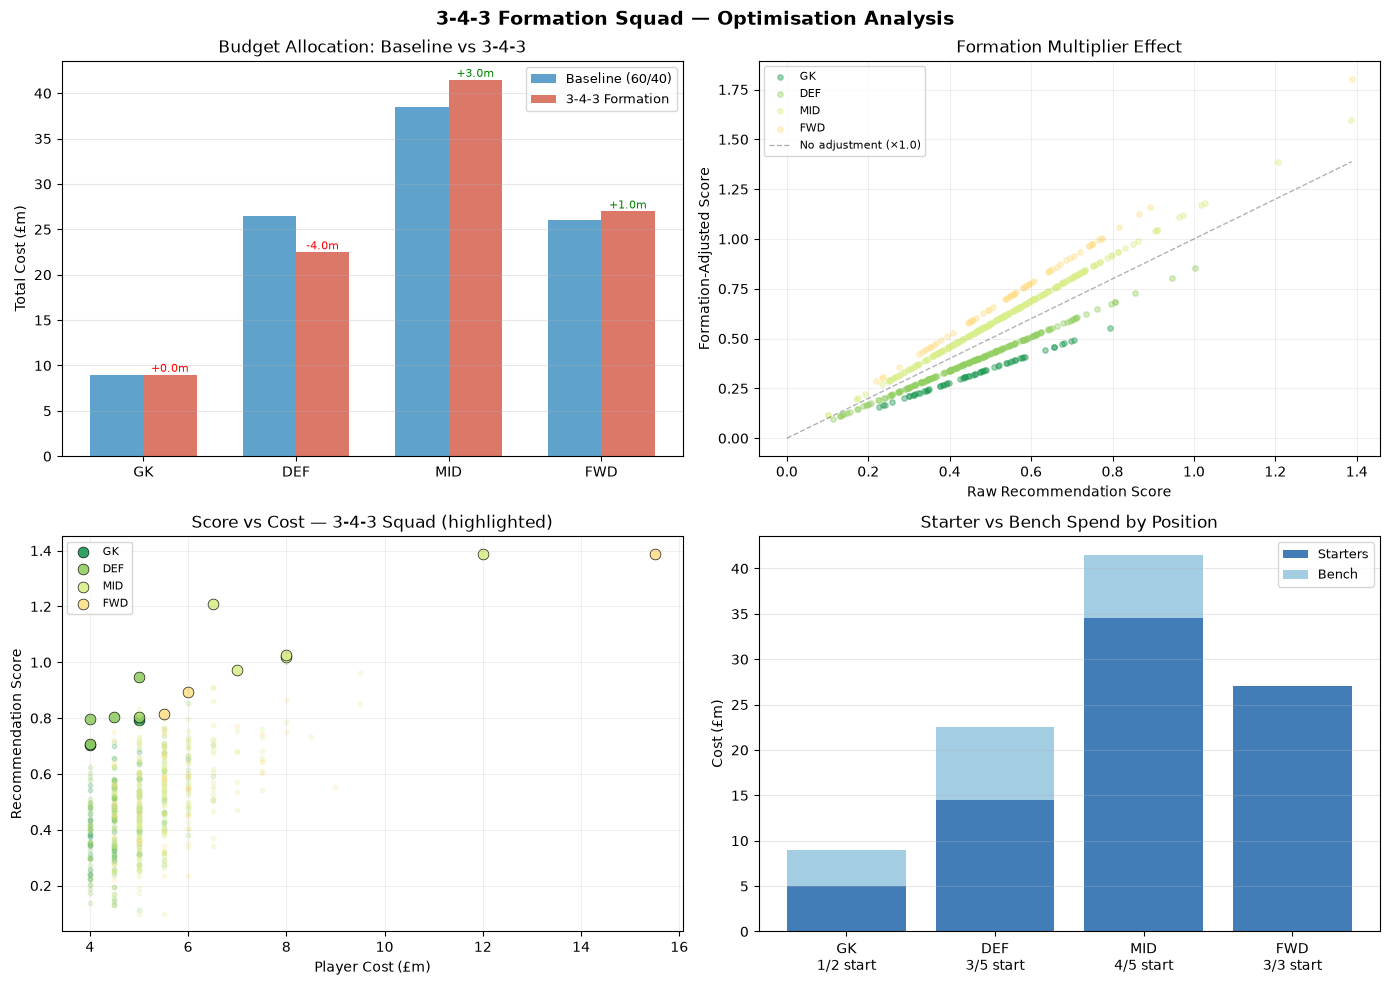

✓ Visualisations saved to /tmp/fpl_squad_343_analysis.png


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('3-4-3 Formation Squad — Optimisation Analysis', fontsize=14, fontweight='bold')

pos_labels = ['GK', 'DEF', 'MID', 'FWD']
colors_343  = ['#1a9850', '#91cf60', '#d9ef8b', '#fee08b']

# ── Panel 1: Budget allocation comparison (if baseline exists) ──────────────
ax1 = axes[0, 0]
if has_baseline:
    bl_costs  = [baseline_squad[baseline_squad['position_id'] == i]['value_millions'].sum() for i in [1,2,3,4]]
    new_costs = [optimal_squad_343[optimal_squad_343['position_id'] == i]['value_millions'].sum() for i in [1,2,3,4]]
    x_pos = np.arange(4)
    width = 0.35
    ax1.bar(x_pos - width/2, bl_costs,  width, label='Baseline (60/40)', color='#4393c3', alpha=0.85)
    ax1.bar(x_pos + width/2, new_costs, width, label='3-4-3 Formation',  color='#d6604d', alpha=0.85)
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels(pos_labels)
    ax1.set_ylabel('Total Cost (£m)')
    ax1.set_title('Budget Allocation: Baseline vs 3-4-3')
    ax1.legend(fontsize=9)
    ax1.grid(axis='y', alpha=0.3)
    for i, (b, n) in enumerate(zip(bl_costs, new_costs)):
        delta = n - b
        ax1.annotate(f'{delta:+.1f}m', xy=(i + width/2, n + 0.3), ha='center', fontsize=8,
                     color='green' if delta > 0 else 'red')
else:
    new_costs = [optimal_squad_343[optimal_squad_343['position_id'] == i]['value_millions'].sum() for i in [1,2,3,4]]
    ax1.bar(pos_labels, new_costs, color=colors_343, alpha=0.85)
    ax1.set_ylabel('Total Cost (£m)')
    ax1.set_title('Budget by Position — 3-4-3')
    ax1.grid(axis='y', alpha=0.3)

# ── Panel 2: Formation multiplier effect on scores ───────────────────────────
ax2 = axes[0, 1]
for pos_id, color in zip([1, 2, 3, 4], colors_343):
    pos_data = players_df[players_df['position_id'] == pos_id]
    ax2.scatter(pos_data['recommendation_score'], pos_data['adjusted_score'],
                alpha=0.4, s=15, color=color, label=POSITION_MAP[pos_id])
max_s = players_df['recommendation_score'].max()
ax2.plot([0, max_s], [0, max_s], 'k--', alpha=0.3, linewidth=1, label='No adjustment (×1.0)')
ax2.set_xlabel('Raw Recommendation Score')
ax2.set_ylabel('Formation-Adjusted Score')
ax2.set_title('Formation Multiplier Effect')
ax2.legend(fontsize=8)
ax2.grid(alpha=0.2)

# ── Panel 3: Score vs Cost scatter (3-4-3 squad highlighted) ────────────────
ax3 = axes[1, 0]
squad_ids_343 = set(optimal_squad_343['player_id'])
for pos_id, color in zip([1, 2, 3, 4], colors_343):
    pool  = players_df[players_df['position_id'] == pos_id]
    in_sq = pool[pool['player_id'].isin(squad_ids_343)]
    out_sq = pool[~pool['player_id'].isin(squad_ids_343)]
    ax3.scatter(out_sq['value_millions'], out_sq['recommendation_score'],
                alpha=0.2, s=10, color=color)
    ax3.scatter(in_sq['value_millions'], in_sq['recommendation_score'],
                alpha=0.9, s=60, color=color, edgecolors='black', linewidths=0.5,
                label=POSITION_MAP[pos_id])
ax3.set_xlabel('Player Cost (£m)')
ax3.set_ylabel('Recommendation Score')
ax3.set_title('Score vs Cost — 3-4-3 Squad (highlighted)')
ax3.legend(fontsize=8)
ax3.grid(alpha=0.2)

# ── Panel 4: Starters vs bench cost split ───────────────────────────────────
ax4 = axes[1, 1]
starter_costs, bench_costs = [], []
for pos_id in [1, 2, 3, 4]:
    pos_sq   = optimal_squad_343[optimal_squad_343['position_id'] == pos_id].sort_values('recommendation_score', ascending=False)
    n_start  = FORMATION_STARTERS[pos_id]
    starters = pos_sq.head(n_start)['value_millions'].sum()
    bench    = pos_sq.tail(len(pos_sq) - n_start)['value_millions'].sum()
    starter_costs.append(starters)
    bench_costs.append(bench)

x_pos = np.arange(4)
ax4.bar(x_pos, starter_costs, label='Starters', color='#2166ac', alpha=0.85)
ax4.bar(x_pos, bench_costs, bottom=starter_costs, label='Bench', color='#92c5de', alpha=0.85)
ax4.set_xticks(x_pos)
ax4.set_xticklabels([f"{POSITION_MAP[i]}\n{FORMATION_STARTERS[i]}/{SQUAD_REQUIREMENTS[i]['count']} start" for i in [1,2,3,4]])
ax4.set_ylabel('Cost (£m)')
ax4.set_title('Starter vs Bench Spend by Position')
ax4.legend(fontsize=9)
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/tmp/fpl_squad_343_analysis.png', dpi=100, bbox_inches='tight')
plt.show()
print("✓ Visualisations saved to /tmp/fpl_squad_343_analysis.png")

## Export

In [8]:
export_343 = optimal_squad_343[[
    'player_id', 'player_name', 'position_id', 'position',
    'value_millions', 'recommendation_score', 'adjusted_score',
    'formation_multiplier', 'value_per_point'
]].copy()

# Tag starters vs bench based on top N scorers per position
export_343['is_starter'] = False
for pos_id in [1, 2, 3, 4]:
    n_start  = FORMATION_STARTERS[pos_id]
    pos_idx  = export_343[export_343['position_id'] == pos_id].nlargest(n_start, 'recommendation_score').index
    export_343.loc[pos_idx, 'is_starter'] = True

export_path = '/tmp/fpl_optimal_squad_343.csv'
export_343.to_csv(export_path, index=False)

print("SQUAD EXPORT — 3-4-3 Formation")
print("=" * 60)
print(f"✓ Exported to: {export_path}")
print()
print(export_343[['player_name', 'position', 'value_millions',
                   'recommendation_score', 'adjusted_score', 'is_starter']].to_string(index=False))
print()
print(f"Starters: {export_343['is_starter'].sum()} | Bench: {(~export_343['is_starter']).sum()}")
print(f"Starter budget: £{export_343[export_343['is_starter']]['value_millions'].sum():.1f}m")
print(f"Bench budget:   £{export_343[~export_343['is_starter']]['value_millions'].sum():.1f}m")

SQUAD EXPORT — 3-4-3 Formation
✓ Exported to: /tmp/fpl_optimal_squad_343.csv

                     player_name   position  value_millions  recommendation_score  adjusted_score  is_starter
                Benjamin Lecomte Goalkeeper             4.0              0.705420        0.493794       False
                   Senne Lammens Goalkeeper             5.0              0.792983        0.555088        True
                      Lewis Dunk   Defender             4.5              0.804970        0.684225        True
                    Jake Bidwell   Defender             4.0              0.795122        0.675854       False
                    Jake O'Brien   Defender             5.0              0.805463        0.684643        True
                    Paddy McNair   Defender             4.0              0.707052        0.600994       False
       Felipe Rodrigues da Silva   Defender             5.0              0.945703        0.803848        True
                    Ismaïla Sarr Midfielde

## Summary

In [ ]:
starter_budget = export_343[export_343['is_starter']]['value_millions'].sum()
bench_budget   = export_343[~export_343['is_starter']]['value_millions'].sum()
avg_ppm        = optimal_squad_343['value_per_point'].mean()

print()
print("╔" + "═" * 78 + "╗")
print("║" + " 3-4-3 FORMATION SQUAD — SUMMARY".center(78) + "║")
print("╚" + "═" * 78 + "╝")
print()
print(f"  Formation:              3-4-3  (1 GK · 3 DEF · 4 MID · 3 FWD)")
print(f"  Optimisation weights:   {SCORE_WEIGHT*100:.0f}% formation-adjusted score + {EFFICIENCY_WEIGHT*100:.0f}% value efficiency")
print(f"  Total squad cost:       £{total_cost_m_343:.1f}m / £{BUDGET_TENTHS/10:.1f}m budget")
print(f"  Total rec. score:       {total_score_343:.3f}")
print(f"  Avg score per player:   {total_score_343/15:.3f}")
print(f"  Avg cost per point:     £{avg_ppm:.2f}m")
print()
print("  Budget split:")
print(f"    Starters (11 players):  £{starter_budget:.1f}m  ({starter_budget/total_cost_m_343*100:.0f}% of budget)")
print(f"    Bench    ( 4 players):  £{bench_budget:.1f}m  ({bench_budget/total_cost_m_343*100:.0f}% of budget)")
print()
print("  Formation multiplier impact:")
for pos_id in [1, 2, 3, 4]:
    pos_sq   = optimal_squad_343[optimal_squad_343['position_id'] == pos_id]
    avg_cost = pos_sq['value_millions'].mean()
    mult     = FORMATION_MULTIPLIERS[pos_id]
    print(f"    {POSITION_MAP[pos_id]}  ×{mult:.2f}  avg player cost: £{avg_cost:.1f}m")
print()
if has_baseline:
    bl_score = baseline_squad['recommendation_score'].sum()
    print(f"  vs Baseline squad:")
    print(f"    Score:         {bl_score:.3f} → {total_score_343:.3f}  (Δ {total_score_343-bl_score:+.3f})")
    print(f"    Players changed: {len(new_picks)} swaps")
print()
print(f"  ✓ Squad exported to: /tmp/fpl_optimal_squad_343.csv")
print()

## Budget Defenders (≤ £4.5m) — Top 5 by Recommendation Score

In [30]:
budget_defenders = (
    players_df[
        (players_df['position_id'] == 3) &
        (players_df['value_millions'] >= 6)
    ]
    .nsmallest(100, 'value_per_point')
    [['player_name', 'value_millions', 'recommendation_score', 'value_per_point']]
    .reset_index(drop=True)
)
budget_defenders.index += 1
budget_defenders.columns = ['Player', 'Price (£m)', 'Rec. Score', 'Cost/Point (£m)']

print("Top 5 Defenders priced ≤ £4.5m by Recommendation Score")
print("=" * 60)
print(budget_defenders.to_string())


Top 5 Defenders priced ≤ £4.5m by Recommendation Score
                                   Player  Price (£m)  Rec. Score  Cost/Point (£m)
1                            Ismaïla Sarr         6.5    1.206942         5.385512
2                        Ryan Gravenberch         6.0    0.903623         6.639941
3                           Jack Grealish         6.5    0.910458         7.139265
4                        Pedro Lomba Neto         6.5    0.908898         7.151514
5         Bruno Guimarães Rodriguez Moura         7.0    0.972128         7.200697
6                             Rio Ngumoha         6.0    0.798317         7.515814
7                         Elliot Anderson         6.5    0.861705         7.543184
8                      Morgan Gibbs-White         8.0    1.027265         7.787671
9        Matheus Santos Carneiro da Cunha         8.0    1.018486         7.854797
10                           Mitoma Kaoru         6.0    0.752069         7.977996
11                       Marcus 

In [ ]:
## Historical Points Distribution by Position (All Seasons)

In [31]:
import glob, os

RAW_DATA_ROOT = (
    '/Users/aaryansehgal/Documents/Codex/2026-07-27/files-mentioned-by-the-user-i'
    '/outputs/fpl_data_pipeline/data/raw'
)

# Load all vaastav GW files across every available season
gw_files = sorted(glob.glob(os.path.join(RAW_DATA_ROOT, 'season=*/source=vaastav/gws__merged_gw.csv')))

frames = []
for path in gw_files:
    season = path.split('season=')[1].split('/')[0]
    df_gw  = pd.read_csv(path, usecols=['position', 'total_points', 'minutes'])
    df_gw['season'] = season
    frames.append(df_gw)

gw_all = pd.concat(frames, ignore_index=True)

# Only include gameweek appearances where player was on the pitch (minutes > 0)
# to exclude DNP zeros that would skew the distribution downward
gw_active = gw_all[gw_all['minutes'] > 0].copy()

# Standardise position labels to uppercase
gw_active['position'] = gw_active['position'].str.upper().str.strip()

seasons_loaded = gw_all['season'].unique().tolist()
print(f"Seasons loaded: {', '.join(sorted(seasons_loaded))}")
print(f"Total GW appearances (all):    {len(gw_all):,}")
print(f"Active appearances (mins > 0): {len(gw_active):,}")
print()
print("Points summary by position (active appearances):")
print(
    gw_active.groupby('position')['total_points']
    .describe(percentiles=[.25, .5, .75])
    .round(2)
    .to_string()
)


Seasons loaded: 2021-22, 2022-23, 2023-24, 2024-25, 2025-26
Total GW appearances (all):    139,039
Active appearances (mins > 0): 56,278

Points summary by position (active appearances):
            count  mean   std  min  25%  50%  75%   max
position                                               
DEF       18928.0  2.70  2.99 -5.0  1.0  1.0  5.0  24.0
FWD        7030.0  3.06  3.27 -2.0  1.0  2.0  4.0  24.0
GK         3822.0  3.41  2.78 -3.0  2.0  2.0  6.0  16.0
GKP          24.0  3.00  1.77  0.0  2.0  3.0  3.0   8.0
MID       26474.0  2.81  2.89 -2.0  1.0  2.0  3.0  26.0


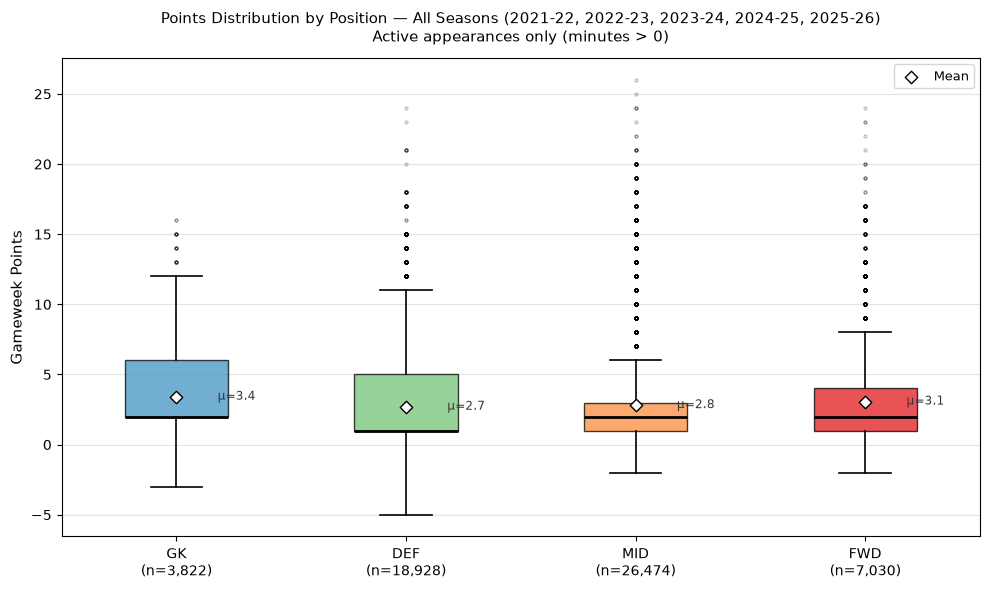

✓ Chart saved to /tmp/fpl_points_by_position_boxplot.png


In [32]:
POS_ORDER  = ['GK', 'DEF', 'MID', 'FWD']
POS_COLORS = {'GK': '#4393c3', 'DEF': '#74c476', 'MID': '#fd8d3c', 'FWD': '#e31a1c'}

plot_data = [
    gw_active.loc[gw_active['position'] == pos, 'total_points'].dropna().values
    for pos in POS_ORDER
]

fig, ax = plt.subplots(figsize=(10, 6))

bp = ax.boxplot(
    plot_data,
    patch_artist=True,
    notch=False,
    medianprops=dict(color='black', linewidth=2),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2),
    flierprops=dict(marker='o', markersize=2, alpha=0.25, linestyle='none'),
)

for patch, pos in zip(bp['boxes'], POS_ORDER):
    patch.set_facecolor(POS_COLORS[pos])
    patch.set_alpha(0.75)

for i, (pos, data) in enumerate(zip(POS_ORDER, plot_data), 1):
    mean_val = data.mean()
    ax.scatter(i, mean_val, marker='D', color='white', edgecolors='black',
               s=40, zorder=5, label='Mean' if i == 1 else '')
    ax.annotate(f'μ={mean_val:.1f}', xy=(i + 0.18, mean_val),
                va='center', fontsize=8.5, color='#333333')

ax.set_xticks(range(1, 5))
ax.set_xticklabels(
    [f"{pos}\n(n={len(d):,})" for pos, d in zip(POS_ORDER, plot_data)],
    fontsize=10
)
ax.set_ylabel('Gameweek Points', fontsize=11)
ax.set_title(
    f'Points Distribution by Position — All Seasons ({", ".join(sorted(seasons_loaded))})\n'
    'Active appearances only (minutes > 0)',
    fontsize=11, pad=12
)
ax.yaxis.grid(True, alpha=0.35)
ax.set_axisbelow(True)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('/tmp/fpl_points_by_position_boxplot.png', dpi=120, bbox_inches='tight')
plt.show()
print("✓ Chart saved to /tmp/fpl_points_by_position_boxplot.png")


## Data-Driven Formation Multipliers & Re-Optimised Squad

Using the historical points distribution to derive position weights:

**Formula:** `multiplier[pos] = (mean_pts[pos] × start_rate[pos]) / mean(all raw weights)`

- `mean_pts` — average GW points per position across all seasons (active appearances)
- `start_rate` — fraction of the squad that starts in a 3-4-3 (e.g. FWD = 3/3 = 1.0)
- Normalisation ensures multipliers are centred around 1.0 so the scale is comparable to the manual baseline

In [33]:
# ── Step 1: Mean points per position from historical data ────────────────────
# Map 'GKP' label (used in one season) to 'GK' for consistency
gw_active['position'] = gw_active['position'].replace('GKP', 'GK')

pos_mean_pts = (
    gw_active[gw_active['position'].isin(['GK', 'DEF', 'MID', 'FWD'])]
    .groupby('position')['total_points']
    .mean()
)

# ── Step 2: 3-4-3 start rates ────────────────────────────────────────────────
start_rates = {
    pos: FORMATION_STARTERS[pos_id] / SQUAD_REQUIREMENTS[pos_id]['count']
    for pos_id, pos in POSITION_MAP.items()
}

# ── Step 3: Raw weight = mean_pts × start_rate ───────────────────────────────
raw_weights = {pos: pos_mean_pts[pos] * start_rates[pos] for pos in POS_ORDER}

# ── Step 4: Normalise to mean = 1.0 ─────────────────────────────────────────
mean_raw = sum(raw_weights.values()) / len(raw_weights)
DATA_DRIVEN_MULTIPLIERS = {
    pos_id: round(raw_weights[pos] / mean_raw, 4)
    for pos_id, pos in POSITION_MAP.items()
}

# ── Print derivation table ────────────────────────────────────────────────────
print("DATA-DRIVEN FORMATION MULTIPLIERS — DERIVATION")
print("=" * 72)
print(f"{'Pos':<5} {'Mean pts':>10} {'Start rate':>12} {'Raw weight':>12} {'Multiplier':>12}  {'vs Manual':>10}")
print("-" * 72)
for pos_id, pos in POSITION_MAP.items():
    mp   = pos_mean_pts[pos]
    sr   = start_rates[pos]
    rw   = raw_weights[pos]
    dm   = DATA_DRIVEN_MULTIPLIERS[pos_id]
    man  = FORMATION_MULTIPLIERS[pos_id]
    diff = dm - man
    sign = f"+{diff:.3f}" if diff >= 0 else f"{diff:.3f}"
    print(f"{pos:<5} {mp:>10.3f} {sr:>11.2f}x {rw:>12.3f} {dm:>12.4f}  ({sign})")
print("-" * 72)
print(f"{'mean':>5} {pos_mean_pts.mean():>10.3f} {'':>12} {mean_raw:>12.3f} {'1.0000':>12}")
print()
print("Interpretation:")
for pos_id, pos in POSITION_MAP.items():
    dm  = DATA_DRIVEN_MULTIPLIERS[pos_id]
    man = FORMATION_MULTIPLIERS[pos_id]
    direction = "↑ more premium" if dm > man else "↓ less premium"
    print(f"  {pos}: {man:.2f} → {dm:.4f}  {direction}")


DATA-DRIVEN FORMATION MULTIPLIERS — DERIVATION
Pos     Mean pts   Start rate   Raw weight   Multiplier   vs Manual
------------------------------------------------------------------------
GK         3.404        0.50x        1.702       0.7885  (+0.089)
DEF        2.698        0.60x        1.619       0.7498  (-0.100)
MID        2.811        0.80x        2.249       1.0418  (-0.108)
FWD        3.065        1.00x        3.065       1.4198  (+0.120)
------------------------------------------------------------------------
 mean      2.994                     2.159       1.0000

Interpretation:
  GK: 0.70 → 0.7885  ↑ more premium
  DEF: 0.85 → 0.7498  ↓ less premium
  MID: 1.15 → 1.0418  ↓ less premium
  FWD: 1.30 → 1.4198  ↑ more premium


In [34]:
# ── Re-run optimisation with data-driven multipliers ────────────────────────
players_dd = players_df.copy()
players_dd['formation_multiplier'] = players_dd['position_id'].map(DATA_DRIVEN_MULTIPLIERS)
players_dd['adjusted_score']       = players_dd['recommendation_score'] * players_dd['formation_multiplier']
players_dd['adjusted_vpp']         = players_dd['value_millions'] / players_dd['adjusted_score']

result_dd = optimize_squad_343_ilp(players_dd, BUDGET_TENTHS, SCORE_WEIGHT, EFFICIENCY_WEIGHT)
if result_dd is None:
    squad_dd, _ = optimize_squad_343_greedy(players_dd, BUDGET_TENTHS, SCORE_WEIGHT, EFFICIENCY_WEIGHT)
    print("⚠ ILP unavailable — used greedy")
else:
    squad_dd, _ = result_dd
    print("✓ ILP optimisation with data-driven multipliers successful")

squad_dd = squad_dd.sort_values('position_id')

# ── Side-by-side comparison ──────────────────────────────────────────────────
print()
print("=" * 90)
print("SQUAD COMPARISON: Manual Multipliers vs Data-Driven Multipliers")
print("=" * 90)

print(f"\n{'':5} {'MANUAL (GK×0.70 DEF×0.85 MID×1.15 FWD×1.30)':^42}  {'DATA-DRIVEN':^35}")
print(f"{'Pos':<5} {'Player':<32} {'£':>5}  {'Score':>6}   {'Player':<32} {'£':>5}  {'Score':>6}")
print("-" * 90)

for pos_id in [1, 2, 3, 4]:
    man_pos = optimal_squad_343[optimal_squad_343['position_id'] == pos_id].sort_values('recommendation_score', ascending=False)
    dd_pos  = squad_dd[squad_dd['position_id'] == pos_id].sort_values('recommendation_score', ascending=False)
    for i in range(max(len(man_pos), len(dd_pos))):
        pos_label = POSITION_MAP[pos_id] if i == 0 else ''
        if i < len(man_pos):
            mp = man_pos.iloc[i]
            man_str = f"{mp['player_name']:<32} £{mp['value_millions']:4.1f}m  {mp['recommendation_score']:6.3f}"
        else:
            man_str = f"{'':42}"
        if i < len(dd_pos):
            dp = dd_pos.iloc[i]
            dd_str  = f"{dp['player_name']:<32} £{dp['value_millions']:4.1f}m  {dp['recommendation_score']:6.3f}"
            changed = '←' if (i < len(man_pos) and dp['player_id'] != man_pos.iloc[i]['player_id']) else ' '
        else:
            dd_str, changed = '', ' '
        print(f"{pos_label:<5} {man_str}   {dd_str}  {changed}")
    # Position budget summary
    man_cost = man_pos['value_millions'].sum()
    dd_cost  = dd_pos['value_millions'].sum()
    delta    = dd_cost - man_cost
    arrow    = f"▲+£{delta:.1f}m" if delta > 0 else (f"▼-£{abs(delta):.1f}m" if delta < 0 else "→")
    print(f"{'':5} {'─'*39} £{man_cost:.1f}m {'':3} {'─'*34} £{dd_cost:.1f}m  {arrow}")
    print()

print("-" * 90)
man_total = optimal_squad_343['recommendation_score'].sum()
dd_total  = squad_dd['recommendation_score'].sum()
man_cost_t = optimal_squad_343['value_millions'].sum()
dd_cost_t  = squad_dd['value_millions'].sum()
print(f"{'TOTAL':<5} {'':32} £{man_cost_t:.1f}m  {man_total:.3f}   {'':32} £{dd_cost_t:.1f}m  {dd_total:.3f}")

# ── Export data-driven squad ─────────────────────────────────────────────────
squad_dd.to_csv('/tmp/fpl_optimal_squad_343_datadriven.csv', index=False)
print(f"\n✓ Data-driven squad exported to: /tmp/fpl_optimal_squad_343_datadriven.csv")


✓ ILP optimisation with data-driven multipliers successful

SQUAD COMPARISON: Manual Multipliers vs Data-Driven Multipliers

      MANUAL (GK×0.70 DEF×0.85 MID×1.15 FWD×1.30)              DATA-DRIVEN            
Pos   Player                               £   Score   Player                               £   Score
------------------------------------------------------------------------------------------
GK    Senne Lammens                    £ 5.0m   0.793   Senne Lammens                    £ 5.0m   0.793   
      Benjamin Lecomte                 £ 4.0m   0.705   Benjamin Lecomte                 £ 4.0m   0.705   
      ─────────────────────────────────────── £9.0m     ────────────────────────────────── £9.0m  →

DEF   Felipe Rodrigues da Silva        £ 5.0m   0.946   Felipe Rodrigues da Silva        £ 5.0m   0.946   
      Jake O'Brien                     £ 5.0m   0.805   Jake O'Brien                     £ 5.0m   0.805   
      Lewis Dunk                       £ 4.5m   0.805   Lewis Dunk

## FDR-Weighted Optimisation — GW1–3 Fixture Difficulty

The recommendation score is further adjusted by each player's fixture difficulty rating (FDR) for the first three gameweeks.

**Method:**
1. Load GW1–3 fixtures from the 2026-27 `endpoint=fixtures` snapshot
2. For each team compute `avg_fdr_3gw` = mean FDR faced across GW1–3 (home vs away correctly assigned)
3. Invert and normalise: `fdr_multiplier = (6 − avg_fdr) / mean(6 − avg_fdr)` so average team = 1.0
4. Blend into the formation-adjusted score: `fdr_score = adjusted_score × (1 − FDR_WEIGHT + FDR_WEIGHT × fdr_multiplier)`

`FDR_WEIGHT` controls how strongly fixtures influence selection (0 = ignore FDR, 1 = fully multiplicative).

In [36]:
import json

FDR_WEIGHT = 0.30   # 30% of adjusted score influenced by GW1-3 fixture difficulty
GW_RANGE   = [1, 2, 3]

# ── Load fixtures JSON ───────────────────────────────────────────────────────
FIXTURES_PATH = (
    '/Users/aaryansehgal/Documents/Codex/2026-07-27/files-mentioned-by-the-user-i'
    '/outputs/fpl_data_pipeline/data/raw/season=2026-27'
    '/endpoint=fixtures/date=2026-07-27/142933_950953_c95f1fe2f364.json'
)
with open(FIXTURES_PATH) as f:
    fixtures_raw = json.load(f)
fixtures_list = fixtures_raw['payload']

# ── Build per-team avg FDR for GW1-3 ────────────────────────────────────────
# team_h_difficulty = how hard the fixture is FOR the home team
# team_a_difficulty = how hard the fixture is FOR the away team
team_fdr_records = {}   # team_id -> list of FDR values faced
for fix in fixtures_list:
    if fix['event'] not in GW_RANGE:
        continue
    th, ta = fix['team_h'], fix['team_a']
    h_diff, a_diff = fix['team_h_difficulty'], fix['team_a_difficulty']
    team_fdr_records.setdefault(th, []).append(h_diff)
    team_fdr_records.setdefault(ta, []).append(a_diff)

team_avg_fdr = {team: sum(fdrs) / len(fdrs) for team, fdrs in team_fdr_records.items()}

# ── Normalise: fdr_multiplier centred at 1.0 ────────────────────────────────
# Invert so easier fixture (lower FDR) → higher score
fdr_inverted = {team: 6 - avg for team, avg in team_avg_fdr.items()}
mean_inverted = sum(fdr_inverted.values()) / len(fdr_inverted)
fdr_multipliers = {team: val / mean_inverted for team, val in fdr_inverted.items()}

# ── Extract player → team mapping from bootstrap JSON ───────────────────────
with open(BOOTSTRAP_PATH) as f:
    bs_raw = json.load(f)
player_team_map = {el['id']: el['team'] for el in bs_raw['payload']['elements']}

# ── Join onto players_df ─────────────────────────────────────────────────────
players_fdr = players_df.copy()
players_fdr['formation_multiplier'] = players_fdr['position_id'].map(DATA_DRIVEN_MULTIPLIERS)
players_fdr['adjusted_score']       = players_fdr['recommendation_score'] * players_fdr['formation_multiplier']
players_fdr['adjusted_vpp']         = players_fdr['value_millions'] / players_fdr['adjusted_score']

players_fdr['team_id']         = players_fdr['player_id'].map(player_team_map)
players_fdr['avg_fdr_3gw']     = players_fdr['team_id'].map(team_avg_fdr).fillna(3.0)  # fallback=average
players_fdr['fdr_multiplier']  = players_fdr['team_id'].map(fdr_multipliers).fillna(1.0)

# Blend FDR into the adjusted score
players_fdr['fdr_adjusted_score'] = (
    players_fdr['adjusted_score'] * (1 - FDR_WEIGHT + FDR_WEIGHT * players_fdr['fdr_multiplier'])
)
players_fdr['fdr_adjusted_vpp'] = players_fdr['value_millions'] / players_fdr['fdr_adjusted_score']

# ── Print FDR summary ─────────────────────────────────────────────────────────
print(f"FDR_WEIGHT = {FDR_WEIGHT} ({FDR_WEIGHT*100:.0f}% weight on GW1-3 fixture difficulty)")
print(f"Gameweeks considered: GW{GW_RANGE[0]}–GW{GW_RANGE[-1]}")
print()
print(f"{'Team ID':>8}  {'Avg FDR':>8}  {'FDR Mult':>10}  {'Rating'}")
print("-" * 45)
for team_id in sorted(team_avg_fdr):
    avg  = team_avg_fdr[team_id]
    mult = fdr_multipliers[team_id]
    rating = "Easy   ▲" if mult > 1.05 else ("Hard   ▼" if mult < 0.95 else "Average →")
    print(f"{team_id:>8}  {avg:>8.2f}  {mult:>10.4f}  {rating}")
print()
print(f"FDR multiplier range: {min(fdr_multipliers.values()):.4f} – {max(fdr_multipliers.values()):.4f}")
print(f"Coverage: {players_fdr['team_id'].notna().sum()} / {len(players_fdr)} players matched to fixture data")


FDR_WEIGHT = 0.3 (30% weight on GW1-3 fixture difficulty)
Gameweeks considered: GW1–GW3

 Team ID   Avg FDR    FDR Mult  Rating
---------------------------------------------
       1      3.33      0.9091  Hard   ▼
       2      3.00      1.0227  Average →
       3      3.67      0.7955  Hard   ▼
       4      2.67      1.1364  Easy   ▲
       5      3.00      1.0227  Average →
       6      3.33      0.9091  Hard   ▼
       7      4.00      0.6818  Hard   ▼
       8      3.33      0.9091  Hard   ▼
       9      3.33      0.9091  Hard   ▼
      10      3.33      0.9091  Hard   ▼
      11      3.00      1.0227  Average →
      12      3.33      0.9091  Hard   ▼
      13      3.00      1.0227  Average →
      14      2.67      1.1364  Easy   ▲
      15      2.67      1.1364  Easy   ▲
      16      2.33      1.2500  Easy   ▲
      17      3.33      0.9091  Hard   ▼
      18      3.00      1.0227  Average →
      19      2.67      1.1364  Easy   ▲
      20      2.33      1.2500  Easy   ▲



In [37]:
# ── Optimiser using fdr_adjusted_score ──────────────────────────────────────
def optimize_squad_fdr_ilp(players_df, budget_tenths=1000,
                            score_weight=0.6, efficiency_weight=0.4):
    if not HAS_PULP:
        return None
    df = players_df.copy()

    max_score = df['fdr_adjusted_score'].max()
    df['norm_score'] = df['fdr_adjusted_score'] / max_score if max_score > 0 else 0

    max_vpp = df['fdr_adjusted_vpp'].max()
    df['eff_score'] = (max_vpp / df['fdr_adjusted_vpp']).clip(upper=2.0)
    df['eff_score'] = df['eff_score'] / df['eff_score'].max()

    df['combined'] = score_weight * df['norm_score'] + efficiency_weight * df['eff_score']

    prob = LpProblem("FPL_FDR", LpMaximize)
    x = {idx: LpVariable(f"p_{row['player_id']}", cat='Binary')
         for idx, row in df.iterrows()}

    prob += lpSum(x[idx] * df.loc[idx, 'combined'] for idx in x)
    prob += lpSum(x[idx] for idx in x) == 15
    prob += lpSum(x[idx] * players_df.loc[idx, 'value_tenths'] for idx in x) <= budget_tenths
    for pos_id in [1, 2, 3, 4]:
        pos_idx = players_df[players_df['position_id'] == pos_id].index.tolist()
        prob += lpSum(x[idx] for idx in pos_idx) == SQUAD_REQUIREMENTS[pos_id]['count']

    prob.solve(PULP_CBC_CMD(msg=0))
    selected = [idx for idx in x if x[idx].varValue == 1]
    return players_df.loc[selected].copy(), prob.objective.value()


result_fdr = optimize_squad_fdr_ilp(players_fdr, BUDGET_TENTHS, SCORE_WEIGHT, EFFICIENCY_WEIGHT)
squad_fdr, _ = result_fdr
squad_fdr = squad_fdr.sort_values('position_id')

print("=" * 90)
print(f"FDR-WEIGHTED SQUAD  (data-driven formation ×  GW1-3 FDR, weight={FDR_WEIGHT})")
print("=" * 90)
print(f"Total players: {len(squad_fdr)}  |  Cost: £{squad_fdr['value_tenths'].sum()/10:.1f}m  |  Score: {squad_fdr['recommendation_score'].sum():.3f}")
print()

for pos_id in [1, 2, 3, 4]:
    pos_sq = squad_fdr[squad_fdr['position_id'] == pos_id].sort_values('recommendation_score', ascending=False)
    print(f"{POSITION_MAP[pos_id]}s  (£{pos_sq['value_millions'].sum():.1f}m total)")
    for i, (_, p) in enumerate(pos_sq.iterrows(), 1):
        tag     = "★" if i <= FORMATION_STARTERS[pos_id] else "·"
        fdr_val = p['avg_fdr_3gw']
        fdr_m   = p['fdr_multiplier']
        ease    = "easy" if fdr_m > 1.05 else ("hard" if fdr_m < 0.95 else "avg ")
        print(f"  {tag} {p['player_name']:35s} £{p['value_millions']:4.1f}m  Score:{p['recommendation_score']:.3f}  FDR:{fdr_val:.2f}({ease})")
    print()

# ── Diff vs data-driven squad (no FDR) ──────────────────────────────────────
dd_ids  = set(squad_dd['player_id'])
fdr_ids = set(squad_fdr['player_id'])
swaps   = fdr_ids - dd_ids
drops   = dd_ids  - fdr_ids
print("-" * 70)
if swaps:
    print(f"Changes vs data-driven squad ({len(swaps)} swap{'s' if len(swaps)>1 else ''}):")
    for _, p in squad_fdr[squad_fdr['player_id'].isin(swaps)].iterrows():
        print(f"  + {p['player_name']:35s} {POSITION_MAP[p['position_id']]}  £{p['value_millions']:.1f}m  FDR:{p['avg_fdr_3gw']:.2f}  fdr_mult:{p['fdr_multiplier']:.3f}")
    for _, p in squad_dd[squad_dd['player_id'].isin(drops)].iterrows():
        fdr_row = players_fdr[players_fdr['player_id'] == p['player_id']]
        fdr_val = fdr_row['avg_fdr_3gw'].values[0] if len(fdr_row) else float('nan')
        fdr_mu  = fdr_row['fdr_multiplier'].values[0] if len(fdr_row) else float('nan')
        print(f"  - {p['player_name']:35s} {POSITION_MAP[p['position_id']]}  £{p['value_millions']:.1f}m  FDR:{fdr_val:.2f}  fdr_mult:{fdr_mu:.3f}")
else:
    print("No changes — FDR weighting confirms the same squad selection.")

squad_fdr.to_csv('/tmp/fpl_optimal_squad_343_fdr.csv', index=False)
print(f"\n✓ FDR-weighted squad exported to: /tmp/fpl_optimal_squad_343_fdr.csv")


FDR-WEIGHTED SQUAD  (data-driven formation ×  GW1-3 FDR, weight=0.3)
Total players: 15  |  Cost: £100.0m  |  Score: 14.219

GKs  (£9.5m total)
  ★ Senne Lammens                       £ 5.0m  Score:0.793  FDR:2.33(easy)
  · Altay Bayındır                      £ 4.5m  Score:0.699  FDR:2.33(easy)

DEFs  (£24.5m total)
  ★ Felipe Rodrigues da Silva           £ 5.0m  Score:0.946  FDR:3.00(avg )
  ★ Matheus Nunes                       £ 6.0m  Score:0.855  FDR:2.67(easy)
  ★ Jake O'Brien                        £ 5.0m  Score:0.805  FDR:3.33(hard)
  · Lewis Dunk                          £ 4.5m  Score:0.805  FDR:3.00(avg )
  · Jake Bidwell                        £ 4.0m  Score:0.795  FDR:4.00(hard)

MIDs  (£39.0m total)
  ★ Bruno Borges Fernandes              £12.0m  Score:1.387  FDR:2.33(easy)
  ★ Ismaïla Sarr                        £ 6.5m  Score:1.207  FDR:3.33(hard)
  ★ Matheus Santos Carneiro da Cunha    £ 8.0m  Score:1.018  FDR:2.33(easy)
  ★ Jack Grealish                       £ 6.5m  Score